In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from FEATURES.features import *
from BACKTEST.backtestCalculateEVS import *
from BACKTEST.backtest import backtestPairs, calculatePairMetrics
# from MODELS.teamInfo import *


In [2]:
import joblib


# Load NGBoost mean and variance models
mean_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_TEST_25v1.pkl')
variance_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_TEST_25v1.pkl')
calibration_factor = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_TEST_25v1.pkl')

# mean_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_TEST_26.pkl')
# variance_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_TEST_26.pkl')
# calibration_factor = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_TEST_26.pkl')

models = {
    'mean': mean_model,
    'variance': variance_model,
    'calibration_factor': calibration_factor
}

features = joblib.load('../MODELS/SAVED_MODELS/feature_listv1.pkl')

print(f"Loaded NGBoost models with calibration factor: {calibration_factor}")
print(f"Number of features: {len(features)}")

Loaded NGBoost models with calibration factor: 3.97
Number of features: 149


In [3]:
pd.set_option('display.max_columns', None)

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
# s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')
df = s26


C:\Users\alexg\AppData\Local\Temp\ipykernel_34216\1066027499.py:5: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')


In [ ]:
# backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
# backtestData = backtestData[(backtestData['BOOKMAKER'] == 'underdog') &  (backtestData['CATEGORY'] == 'player_points')]
# backtestData.sample(5)


/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_33430/1633982547.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
37291,37291,37291,37291,Jayson Tatum,player_points,underdog,over,30.5,-137,Minnesota Timberwolves,Boston Celtics,a480ee72fa8d5276d08ce1f84356058f,2025-01-03T00:30:00Z,2025-01-02,NaN,NaN,NaN,over
25974,25974,25974,25974,Zach LaVine,player_points,underdog,under,22.5,-137,Chicago Bulls,Charlotte Hornets,588eb7f774dce2830329b5f78d43baa1,2024-12-14T01:10:00Z,2024-12-13,NaN,NaN,NaN,under
178145,178145,178145,94544,DeMar DeRozan,player_points,underdog,under,22.5,-137,Charlotte Hornets,Sacramento Kings,NaN,NaN,2025-04-04,game,22.5,133.0,under
167719,167719,167719,81396,Jimmy Butler,player_points,underdog,under,17.5,-137,San Antonio Spurs,Golden State Warriors,NaN,NaN,2025-03-30,game,12.5,100.0,under
80246,80246,80246,80246,Aaron Gordon,player_points,underdog,over,11.5,-137,Denver Nuggets,Portland Trail Blazers,NaN,NaN,2025-02-13,game,11.5,102.0,over


In [4]:
backtestData= pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/s26props.csv')

backtestData = backtestData[(backtestData['BOOKMAKER'] == 'Underdog') &  
                            (backtestData['CATEGORY'] == 'player_points')]
backtestData.rename(columns={'COMMENCE_TIME': 'GAME_DATE', 'OVER/UNDER': 'SIDE'}, inplace=True)
backtestData

,Unnamed: 0,BOOKMAKER,CATEGORY,NAME,SIDE,LINE,ODDS,GAME_DATE,LAST_UPDATE,version https://git-lfs.github.com/spec/v1
0,0,Underdog,player_points,Pascal Siakam,Over,26.5,-137.0,2025-10-31,2025-10-31T21:57:25Z,NaN
1,1,Underdog,player_points,Pascal Siakam,Under,26.5,-137.0,2025-10-31,2025-10-31T21:57:25Z,NaN
2,2,Underdog,player_points,Kristaps Porzingis,Over,18.5,-137.0,2025-10-31,2025-10-31T21:57:25Z,NaN
3,3,Underdog,player_points,Kristaps Porzingis,Under,18.5,-137.0,2025-10-31,2025-10-31T21:57:25Z,NaN
4,4,Underdog,player_points,Aaron Nesmith,Over,15.5,-137.0,2025-10-31,2025-10-31T21:57:25Z,NaN
...,...,...,...,...,...,...,...,...,...,...
43893,43893,Underdog,player_points,Gabe Vincent,Under,6.5,-137.0,2025-10-27,2025-10-26T15:25:04Z,NaN
43894,43894,Underdog,player_points,Jake LaRavia,Over,5.5,-137.0,2025-10-27,2025-10-26T15:25:04Z,NaN
43895,43895,Underdog,player_points,Jake LaRavia,Under,5.5,-137.0,2025-10-27,2025-10-26T15:25:04Z,NaN
43896,43896,Underdog,player_points,Isaac Jones,Over,4.5,-137.0,2025-10-27,2025-10-26T15:25:04Z,NaN


In [11]:
date = '2025-10-31'

results = backtestPairs(
    data=s26,
    backtestData=backtestData,
    gameDate=date,
    models=models,  
    features=features,
    edge_threshold=4.5, 
    top_n=15, 
    variance_inflation=1.1, 
    use_monte_carlo=True, n_simulations=10000, max_kelly=0.25, stake=10, max_player_appearances=5)


# Comprehensive results analysis
if not results.empty:
    print("=" * 60)
    print("PAIR BETTING RESULTS ANALYSIS")
    print("=" * 60)
    
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Calculate profit/loss
    total_profit = results['pair_profit'].sum() * 3
    avg_profit = results['pair_profit'].mean() * 3
    
    print(f"Total Bets: {total_bets}")
    print(f"Wins: {total_wins}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Total Profit: ${total_profit:.2f}")
    print(f"Average Profit per Bet: ${avg_profit:.2f}")

results

Starting backtest for pairs on 2025-10-31
Applied player frequency limit (5 max appearances per player)
Selected 43 combinations from 140 candidates
Time taken for pairs: 2.732830762863159 seconds
Time taken for sorting: 2.73333477973938 seconds
Time taken for dropping duplicates: 2.7363405227661133 seconds
Time taken for iterating over evData: 2.7363405227661133 seconds
Time taken for backtest_results: 2.747365713119507 seconds
PAIR BETTING RESULTS ANALYSIS
Total Bets: 15
Wins: 11
Win Rate: 73.33%
Total Profit: $540.00
Average Profit per Bet: $36.00


,NAME 1,NAME 2,LINE 1,LINE 2,PREDICTION 1,PREDICTION 2,MODEL SIDE 1,MODEL SIDE 2,PROB 1,PROB 2,PROB BOTH,EDGE 1,EDGE 2,COMBINED EDGE,EV$,KELLY FULL,RECOMMENDATION,INTERVAL WIDTH 1,INTERVAL WIDTH 2,SIGMA 1,SIGMA 2,SIGMA FLAG 1,SIGMA FLAG 2,EXPECTED ROI,SIMULATION METHOD,actual1,actual2,leg1_won,leg2_won,pair_won,pair_recommendation,pair_profit,selection,date
0,Andre Drummond,Brandon Ingram,3.5,19.5,5.85,23.80,over,over,0.777,0.738,0.5729,0.199,0.160,0.239,7.19,0.359,0,15.66,26.85,5.01,6.85,Med,High,71.9,Monte Carlo,6,20,1,1,1,0,20.0,top_ev,2025-10-31
1,Andre Drummond,Scottie Barnes,3.5,17.5,5.85,22.01,over,over,0.777,0.726,0.5638,0.199,0.148,0.230,6.91,0.346,0,15.66,29.86,5.01,7.62,Med,High,69.1,Monte Carlo,6,14,1,0,0,0,-10.0,top_ev,2025-10-31
2,Keaton Wallace,Andre Drummond,4.5,3.5,6.15,5.85,over,over,0.712,0.773,0.5505,0.134,0.195,0.216,6.51,0.326,0,15.92,15.66,4.98,5.01,Low,Med,65.1,Monte Carlo,11,6,1,1,1,0,20.0,top_ev,2025-10-31
3,Quenton Jackson,Andre Drummond,6.5,3.5,8.79,5.85,over,over,0.706,0.773,0.5460,0.128,0.195,0.212,6.38,0.319,0,20.72,15.66,6.09,5.01,High,Med,63.8,Monte Carlo,15,6,1,1,1,0,20.0,top_ev,2025-10-31
4,Keaton Wallace,Brandon Ingram,4.5,19.5,6.15,23.80,over,over,0.712,0.738,0.5253,0.134,0.160,0.191,5.76,0.288,0,15.92,26.85,4.98,6.85,Low,High,57.6,Monte Carlo,11,20,1,1,1,0,20.0,top_ev,2025-10-31
5,Quenton Jackson,Brandon Ingram,6.5,19.5,8.79,23.80,over,over,0.706,0.738,0.5211,0.128,0.160,0.187,5.63,0.282,0,20.72,26.85,6.09,6.85,High,High,56.3,Monte Carlo,15,20,1,1,1,0,20.0,top_ev,2025-10-31
6,Tyrese Maxey,Brandon Ingram,29.5,19.5,24.93,23.80,under,over,0.704,0.738,0.5191,0.126,0.160,0.185,5.57,0.279,0,32.16,26.85,8.20,6.85,High,High,55.7,Monte Carlo,26,20,1,1,1,0,20.0,top_ev,2025-10-31
7,Keaton Wallace,Scottie Barnes,4.5,17.5,6.15,22.01,over,over,0.712,0.726,0.5170,0.134,0.148,0.183,5.51,0.275,0,15.92,29.86,4.98,7.62,Low,High,55.1,Monte Carlo,11,14,1,0,0,0,-10.0,top_ev,2025-10-31
8,Quenton Jackson,Scottie Barnes,6.5,17.5,8.79,22.01,over,over,0.706,0.726,0.5128,0.128,0.148,0.179,5.39,0.269,0,20.72,29.86,6.09,7.62,High,High,53.9,Monte Carlo,15,14,1,0,0,0,-10.0,top_ev,2025-10-31
9,Tyrese Maxey,Scottie Barnes,29.5,17.5,24.93,22.01,under,over,0.704,0.726,0.5109,0.126,0.148,0.177,5.33,0.266,1,32.16,29.86,8.20,7.62,High,High,53.3,Monte Carlo,26,14,1,0,0,1,-10.0,top_ev,2025-10-31


## Points

In [5]:
uniqueDates = sorted(s26['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPairs(
        data=s26,
        backtestData=backtestData,
        gameDate=date,
        models=models,  
        features=features,
        edge_threshold=4, 
        top_n=5, 
        variance_inflation=1.1, 
        use_monte_carlo=False, n_simulations=10000, max_kelly=0.25, stake=10, max_player_appearances=5)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2025-10-21... 1/25
Starting backtest for pairs on 2025-10-21
No bets found for 2025-10-21
  No results for 2025-10-21
Processing 2025-10-22... 2/25
Starting backtest for pairs on 2025-10-22
No bets found for 2025-10-22
  No results for 2025-10-22
Processing 2025-10-23... 3/25
Starting backtest for pairs on 2025-10-23
Applied player frequency limit (5 max appearances per player)
Selected 15 combinations from 18 candidates
Time taken for pairs: 0.6537928581237793 seconds
Time taken for sorting: 0.6537928581237793 seconds
Time taken for dropping duplicates: 0.6563048362731934 seconds
Time taken for iterating over evData: 0.6563048362731934 seconds
Time taken for backtest_results: 0.6583044528961182 seconds
  ✓ Processed 5 bets
Processing 2025-10-24... 4/25
Starting backtest for pairs on 2025-10-24
Applied player frequency limit (5 max appearances per player)
Selected 106 combinations from 851 candidates
Time taken for pairs: 4.510658502578735 seconds
Time taken for sorting: 4.5

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 75
   Wins: 31
   Hit Rate: 41.33%
   Total Profit: $180.00
   Total Staked: $750.00
   ROI: 24.00%
   Volatility: $47.39
   Max Drawdown: $-70.00
   Sharpe Ratio: 4.838

   PROBABILITY METRICS:
   Brier Score: 0.2706 (lower is better)
   Log Loss: 0.7380 (lower is better)
   AUC-ROC: 0.6199 (higher is better)
   Samples: 75

 RECOMMENDED BETS ANALYSIS (Edge > 0.60):
   Total Bets: 24
   Wins: 14
   Hit Rate: 58.33%
   Total Profit: $180.00
   Total Staked: $240.00
   ROI: 75.00%
   Volatility: $33.70
   Max Drawdown: $-20.00
   Sharpe Ratio: 12.755


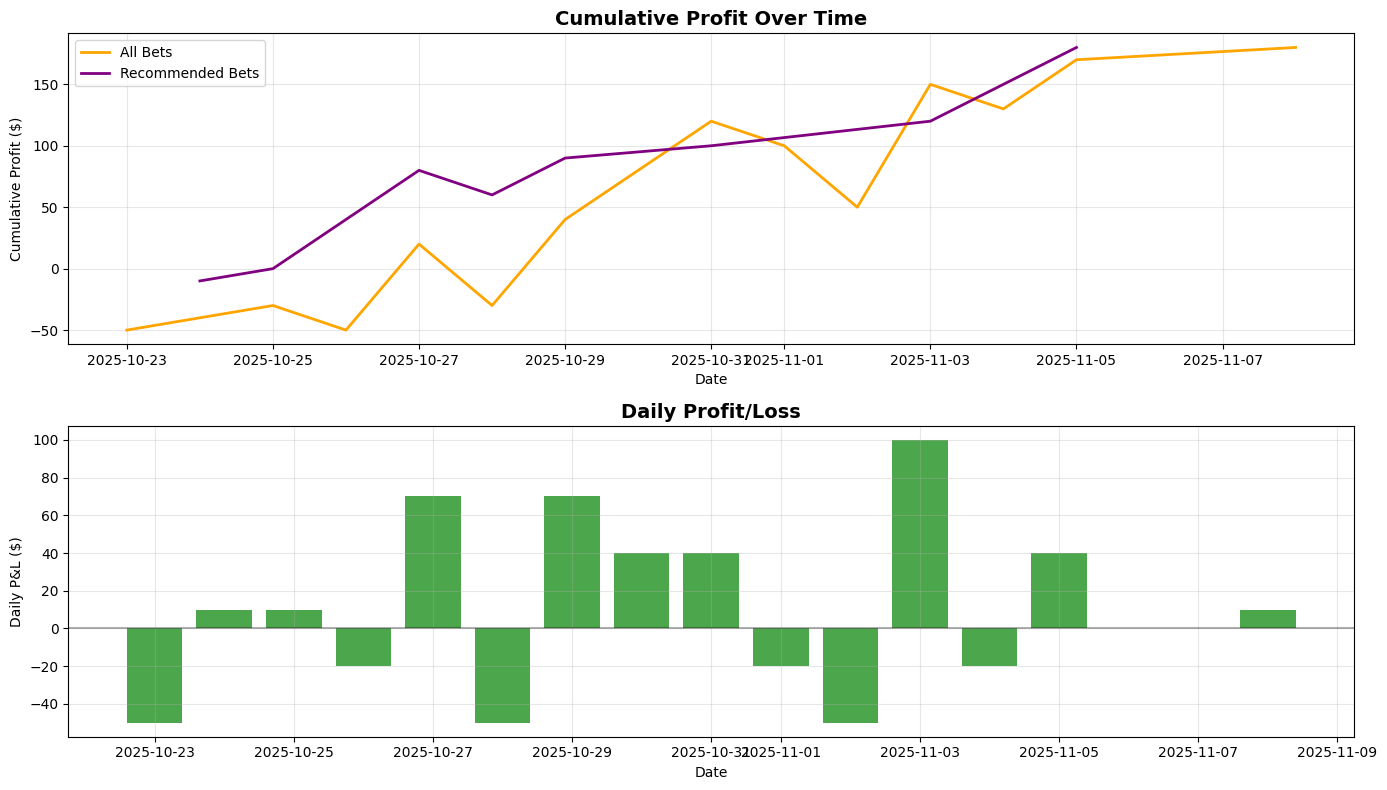

In [6]:
all_metrics = calculatePairMetrics(final_results, stake=10)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=10)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")
    
    # Display probability metrics
    if 'probability_metrics' in all_metrics and 'error' not in all_metrics['probability_metrics']:
        prob_metrics = all_metrics['probability_metrics']
        print(f"\n   PROBABILITY METRICS:")
        print(f"   Brier Score: {prob_metrics.get('brier_score', 'N/A'):.4f} (lower is better)")
        print(f"   Log Loss: {prob_metrics.get('log_loss', 'N/A'):.4f} (lower is better)")
        if not np.isnan(prob_metrics.get('auc_roc', np.nan)):
            print(f"   AUC-ROC: {prob_metrics.get('auc_roc', 'N/A'):.4f} (higher is better)")
        else:
            print(f"   AUC-ROC: NaN ({prob_metrics.get('auc_roc_note', 'Only one class present')})")
        print(f"   Samples: {prob_metrics.get('n_samples', 'N/A')}")

if rec_metrics:
    print("\n RECOMMENDED BETS ANALYSIS (Edge > 0.60):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")
    
# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()